In [1]:
# ============================================================
# SHARED RF EVAL HELPER
# One function for both the random-split and temporal-split RF
# evaluations instead of copy-pasting the same metric block twice.
# ============================================================

def evaluate_rf_model(model, X_test, y_test, label):
    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    roc = roc_auc_score(y_test, probs)
    pr = average_precision_score(y_test, probs)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print("=" * 60)
    print(label)
    print("=" * 60)
    print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall   : {recall_score(y_test, preds):.4f}")
    print(f"F1-score : {f1_score(y_test, preds):.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"PR-AUC   : {pr:.4f}\n")

    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))

    print("\nClassification report:")
    print(classification_report(y_test, preds, digits=4))

    return roc, pr, recall, f1


In [125]:
print("⟳ Loading Random Forest model (random split)...")
best_rf = joblib.load("models/random_forest/random_forest_best_randomsplit.joblib")
print("✅ Done.\n")

random_rf_roc_auc, random_rf_pr_auc, random_rf_recall, random_rf_f1 = evaluate_rf_model(
    best_rf,
    X_test_rf,
    y_test_rf,
    "Random Forest — Random split (Experiment 1)",
)


⟳ Loading Random Forest model (random split)...
✅ Done.

Random Forest — Random split (Experiment 1)
Accuracy : 0.9902
Precision: 0.9812
Recall   : 0.9175
F1-score : 0.9483
ROC-AUC  : 0.9972
PR-AUC   : 0.9842

Confusion matrix:
[[8388   16]
 [  75  834]]

Classification report:
              precision    recall  f1-score   support

           0     0.9911    0.9981    0.9946      8404
           1     0.9812    0.9175    0.9483       909

    accuracy                         0.9902      9313
   macro avg     0.9862    0.9578    0.9714      9313
weighted avg     0.9902    0.9902    0.9901      9313



In [126]:
print("⟳ Loading Random Forest model (temporal split, Experiment 2B)...")
exp2b_model = joblib.load("models/random_forest/random_forest_exp2b.joblib")
print("✅ Done.\n")

temporal_rf_roc, temporal_rf_pr, temporal_rf_recall, temporal_rf_f1 = evaluate_rf_model(
    exp2b_model,
    X_test_temporal,
    y_test_temporal,
    "Random Forest — Temporal split (Experiment 2B)",
)


⟳ Loading Random Forest model (temporal split, Experiment 2B)...
✅ Done.

Random Forest — Temporal split (Experiment 2B)
Accuracy : 0.9744
Precision: 0.9375
Recall   : 0.4779
F1-score : 0.6331
ROC-AUC  : 0.9595
PR-AUC   : 0.7047

Confusion matrix:
[[8420   13]
 [ 213  195]]

Classification report:
              precision    recall  f1-score   support

           0     0.9753    0.9985    0.9868      8433
           1     0.9375    0.4779    0.6331       408

    accuracy                         0.9744      8841
   macro avg     0.9564    0.7382    0.8099      8841
weighted avg     0.9736    0.9744    0.9704      8841



In [127]:
print("Feature importance (random-split RF):")
rf_search = joblib.load("models/random_forest/rf_random_search_randomsplit.joblib")
feature_importance = (
    pd.DataFrame({
        "feature": X_train_rf.columns,
        "importance": best_rf.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)
)
print(f"{feature_importance.head(20)}\n")

personal_values = feature_importance.loc[
    feature_importance["feature"].str[1:].astype(int) < 95,
    "importance"
].tolist()
print(
    f"Aggregated personal features' importance value: {sum(personal_values):.4f}\n"
    f"Aggregated neighborhood graph features' importance value: {1 - sum(personal_values):.4f}\n"
)

print("Saving the tuning results...")
cv_results = pd.DataFrame(rf_search.cv_results_)
cv_results = cv_results.sort_values("rank_test_score")
cv_results.to_csv(
    "models/random_forest/rf_random_search_results_randomsplit.csv",
    index=False,
)


Feature importance (random-split RF):
    feature  importance
52      f54    0.114984
4        f6    0.098554
13      f15    0.087939
54      f56    0.071851
89      f91    0.040306
162    f164    0.037538
40      f42    0.030103
64      f66    0.024218
58      f60    0.024190
131    f133    0.023910
159    f161    0.019922
15      f17    0.019390
60      f62    0.018203
46      f48    0.017777
17      f19    0.017490
66      f68    0.016675
42      f44    0.015183
48      f50    0.014429
79      f81    0.014227
65      f67    0.012103

Aggregated personal features' importance value: 0.7817
Aggregated neighborhood graph features' importance value: 0.2183

Saving the tuning results...


In [140]:
results = pd.DataFrame([
    {
        "model": "LOF",
        "experiment": "Temporal",
        "roc_auc": temporal_lof_roc,
        "pr_auc": temporal_lof_pr
    },
    {
        "model": "Isolation Forest",
        "experiment": "Temporal",
        "roc_auc": temporal_if_roc,
        "pr_auc": temporal_if_pr
    },
    {
        "model": "Random Forest",
        "experiment": "Temporal",
        "roc_auc": temporal_rf_roc,   
        "pr_auc": temporal_rf_pr,
        "recall": temporal_rf_recall,
        "f1": temporal_rf_f1
    },
    {
        "model": "LOF",
        "experiment": "Random label holdout",
        "roc_auc": random_lof_roc_auc,
        "pr_auc": random_lof_pr_auc
    },
    {
        "model": "Isolation Forest",
        "experiment": "Random label holdout",
        "roc_auc": random_if_roc_auc,
        "pr_auc": random_if_pr_auc
    },
    {
        "model": "Random Forest",
        "experiment": "Random label holdout",
        "roc_auc": random_rf_roc_auc,  
        "pr_auc": random_rf_pr_auc,
        "recall": random_rf_recall,
        "f1": random_rf_f1
    }
])

display(results)

results.to_csv(
    "models/models_comparison.csv",
    index=False
)

print("Saved.")

# ============================================================
# Recall and F1 are omitted for LOF and Isolation Forest because these metrics depend on the contamination threshold, a fixed hyperparameter 
# rather than a learned decision boundary. ROC-AUC and PR-AUC, which depend only on score ranking, are the appropriate comparison metrics between 
# supervised and unsupervised approaches.
# ============================================================

,model,experiment,roc_auc,pr_auc,recall,f1
0,LOF,Temporal,0.460650,0.047858,NaN,NaN
1,Isolation Forest,Temporal,0.280879,0.029305,NaN,NaN
2,Random Forest,Temporal,0.959476,0.704713,0.477941,0.633117
3,LOF,Random label holdout,0.227117,0.058514,NaN,NaN
4,Isolation Forest,Random label holdout,0.094723,0.052174,NaN,NaN
5,Random Forest,Random label holdout,0.997159,0.984200,0.917492,0.948266


Saved.


In [25]:
# ============================================================
# ROC CURVE PLOTS
# Setup: dark theme matching the Django UI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({
    "figure.facecolor":  "#0b0d14",
    "axes.facecolor":    "#131720",
    "axes.edgecolor":    "#1c2033",
    "axes.labelcolor":   "#d4dae8",
    "axes.titlecolor":   "#d4dae8",
    "xtick.color":       "#4f5a78",
    "ytick.color":       "#4f5a78",
    "text.color":        "#d4dae8",
    "grid.color":        "#1c2033",
    "grid.linewidth":    0.8,
    "font.family":       "monospace",
    "legend.framealpha": 0.0,
    "legend.edgecolor":  "#1c2033",
})

# Colour palette — matches Django templates exactly
C_RF  = "#f7931a"   # Bitcoin orange  — Random Forest
C_LOF = "#60a5fa"   # Blue            — LOF
C_IF  = "#a78bfa"   # Purple          — Isolation Forest
C_DIAG = "#2d3550"  # Muted           — random-guess diagonal

In [26]:
# ============================================================
# COMPUTE RAW SCORES FOR EVERY MODEL × SPLIT
# roc_curve() needs continuous scores, not binary predictions.
#   RF  → predict_proba()[:,1]      (probability of illicit)
#   IF  → -score_samples()          (negated: higher = more anomalous)
#   LOF → -score_samples()          (same convention)
# ============================================================

# ── Load models ──────────────────────────────────────────────
rf_temporal  = joblib.load("models/random_forest/random_forest_exp2b.joblib")
rf_random    = joblib.load("models/random_forest/random_forest_best_randomsplit.joblib")

lof_temporal = joblib.load("models/lof/lof_final.joblib")
lof_random   = joblib.load("models/lof/lof_randomsplit.joblib")

if_temporal  = joblib.load("models/isolation_forest/isolation_forest_best.joblib")
if_random    = joblib.load("models/isolation_forest/isolation_forest_random.joblib")

# ── Temporal split scores ─────────────────────────────────────
# X_test_temporal, y_test_temporal  → from 02_preprocessing.ipynb kernel state
# X_test_random,   y_test_random    → from random_split_unsupervised.ipynb

rf_temporal_scores  = rf_temporal.predict_proba(X_test_temporal)[:, 1]
lof_temporal_scores = -lof_temporal.score_samples(X_test_temporal)
if_temporal_scores  = -if_temporal.score_samples(X_test_temporal)

# ── Random split scores ───────────────────────────────────────
# Note: RF random split used a different test set (X_test_rf / y_test_rf)
rf_random_scores  = rf_random.predict_proba(X_test_rf)[:, 1]
lof_random_scores = -lof_random.score_samples(X_test_random)
if_random_scores  = -if_random.score_samples(X_test_random)

# ── Build fpr/tpr curves for each ────────────────────────────
def make_curve(y_true, scores):
    fpr, tpr, _ = roc_curve(y_true, scores)
    return fpr, tpr, auc(fpr, tpr)

rf_t_fpr,  rf_t_tpr,  rf_t_auc  = make_curve(y_test_temporal, rf_temporal_scores)
lof_t_fpr, lof_t_tpr, lof_t_auc = make_curve(y_test_temporal, lof_temporal_scores)
if_t_fpr,  if_t_tpr,  if_t_auc  = make_curve(y_test_temporal, if_temporal_scores)

rf_r_fpr,  rf_r_tpr,  rf_r_auc  = make_curve(y_test_rf,     rf_random_scores)
lof_r_fpr, lof_r_tpr, lof_r_auc = make_curve(y_test_random, lof_random_scores)
if_r_fpr,  if_r_tpr,  if_r_auc  = make_curve(y_test_random, if_random_scores)

print("Temporal split AUCs:")
print(f"  RF:  {rf_t_auc:.4f}")
print(f"  LOF: {lof_t_auc:.4f}")
print(f"  IF:  {if_t_auc:.4f}")

print("\nRandom split AUCs:")
print(f"  RF:  {rf_r_auc:.4f}")
print(f"  LOF: {lof_r_auc:.4f}")
print(f"  IF:  {if_r_auc:.4f}")

Temporal split AUCs:
  RF:  0.9595
  LOF: 0.4607
  IF:  0.2809

Random split AUCs:
  RF:  0.9972
  LOF: 0.2271
  IF:  0.0947


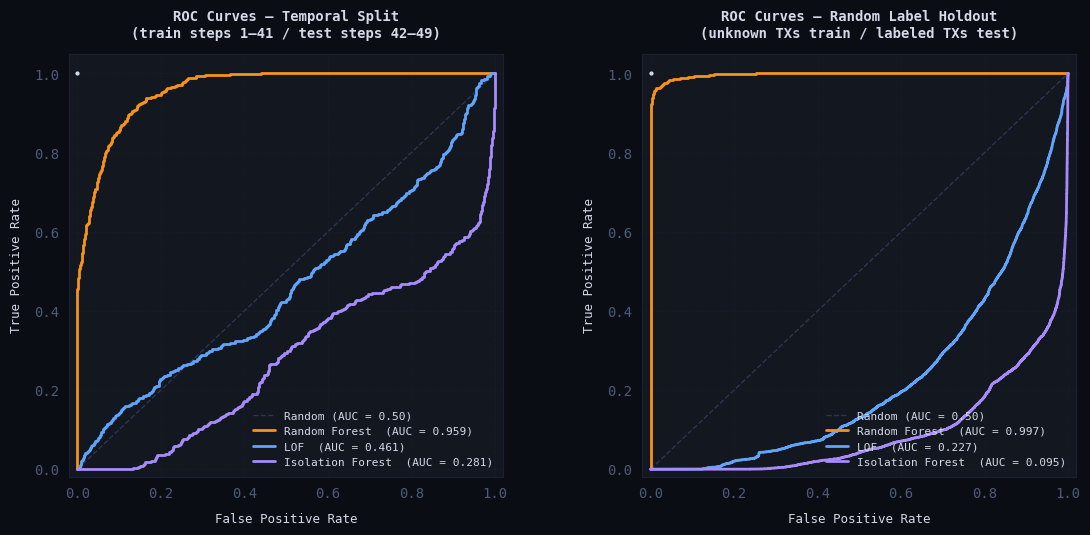

Saved → docs/thesis/figures/roc_curves_all_models.png


In [29]:
# ============================================================
# PLOT — side by side: temporal split | random split
# Saved as a single PNG for the thesis.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.subplots_adjust(wspace=0.32)


def draw_roc_panel(ax, title, curves):
    """
    curves: list of (fpr, tpr, auc_score, label, color, linestyle)
    """
    # Random-guess diagonal
    ax.plot([0, 1], [0, 1], color=C_DIAG, linewidth=1,
            linestyle="--", label="Random (AUC = 0.50)")

    for fpr, tpr, auc_score, label, color, ls in curves:
        ax.plot(
            fpr, tpr,
            color=color,
            linewidth=2,
            linestyle=ls,
            label=f"{label}  (AUC = {auc_score:.3f})",
        )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=9, labelpad=8)
    ax.set_ylabel("True Positive Rate", fontsize=9, labelpad=8)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="lower right")

    # AUC = 1.0 reference corner dot
    ax.plot(0, 1, marker=".", color="#d4dae8", markersize=4, zorder=5)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))


# ── Panel 1: Temporal split ───────────────────────────────────
draw_roc_panel(
    axes[0],
    "ROC Curves — Temporal Split\n(train steps 1–41 / test steps 42–49)",
    [
        (rf_t_fpr,  rf_t_tpr,  rf_t_auc,  "Random Forest", C_RF,  "solid"),
        (lof_t_fpr, lof_t_tpr, lof_t_auc, "LOF",           C_LOF, "solid"),
        (if_t_fpr,  if_t_tpr,  if_t_auc,  "Isolation Forest", C_IF, "solid"),
    ]
)

# ── Panel 2: Random split ─────────────────────────────────────
draw_roc_panel(
    axes[1],
    "ROC Curves — Random Label Holdout\n(unknown TXs train / labeled TXs test)",
    [
        (rf_r_fpr,  rf_r_tpr,  rf_r_auc,  "Random Forest", C_RF,  "solid"),
        (lof_r_fpr, lof_r_tpr, lof_r_auc, "LOF",           C_LOF, "solid"),
        (if_r_fpr,  if_r_tpr,  if_r_auc,  "Isolation Forest", C_IF, "solid"),
    ]
)

plt.savefig(
    "../docs/thesis/figures/roc_curves_all_models.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()
print("Saved → docs/thesis/figures/roc_curves_all_models.png")

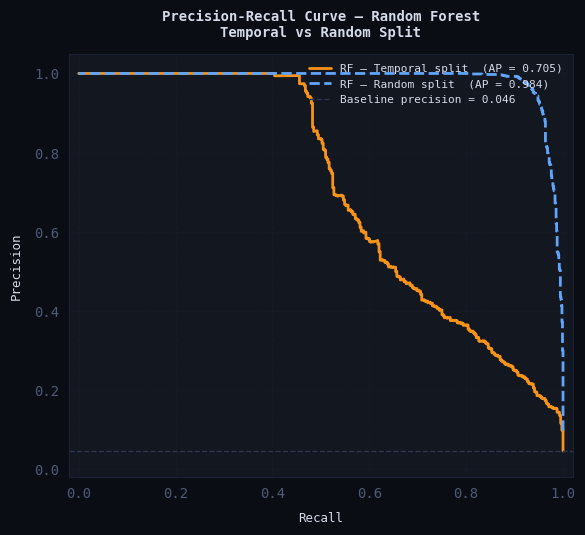

Saved → docs/thesis/figures/pr_curve_random_forest.png


In [31]:
# ============================================================
# PRECISION-RECALL CURVE — Random Forest only
# More informative than ROC on heavily imbalanced data because
# it focuses on the minority class (illicit) without flattering
# the model with the large number of true negatives.
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(6.5, 5.5))

for scores, y_true, label, color, ls in [
    (rf_temporal_scores, y_test_temporal, "Temporal split", C_RF,  "solid"),
    (rf_random_scores,   y_test_rf,       "Random split",   C_LOF, "dashed"),
]:
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    ax.plot(rec, prec, color=color, linewidth=2,
            linestyle=ls, label=f"RF — {label}  (AP = {ap:.3f})")

# Baseline = illicit prevalence in labeled set
baseline = y_test_temporal.mean()
ax.axhline(baseline, color=C_DIAG, linewidth=1, linestyle="--",
           label=f"Baseline precision = {baseline:.3f}")

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("Recall", fontsize=9, labelpad=8)
ax.set_ylabel("Precision", fontsize=9, labelpad=8)
ax.set_title(
    "Precision-Recall Curve — Random Forest\nTemporal vs Random Split",
    fontsize=10, fontweight="bold", pad=12
)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=8, loc="upper right")
ax.set_facecolor("#131720")
fig.set_facecolor("#0b0d14")

plt.savefig(
    "../docs/thesis/figures/pr_curve_random_forest.png",
    dpi=180,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()
print("Saved → docs/thesis/figures/pr_curve_random_forest.png")

In [22]:
# ============================================================
# THRESHOLD ANALYSIS — Temporal Split Only
# Shows how Precision, Recall, F1, FPR, and the confusion
# matrix change as the decision threshold moves.
#
# RF:       threshold on predict_proba score (0 → 1)
# LOF / IF: threshold on -score_samples     (higher = more anomalous)
#           expressed as the top-N% most anomalous transactions
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

def threshold_sweep(y_true, scores, thresholds, score_type="prob"):
    """
    Sweep decision thresholds and collect metrics at each point.

    Parameters
    ----------
    y_true     : array-like  — ground truth binary labels
    scores     : array-like  — continuous model scores
    thresholds : list        — values to try
    score_type : "prob"      — thresholds are raw score cutoffs
                 "percentile"— thresholds are top-N% cutoffs (for IF/LOF)

    Returns
    -------
    pd.DataFrame with one row per threshold
    """
    y_true  = np.array(y_true)
    scores  = np.array(scores)
    rows    = []

    for t in thresholds:
        if score_type == "percentile":
            # Flag the top t% highest-scoring transactions as anomalous
            cutoff = np.percentile(scores, 100 - t)
            preds  = (scores >= cutoff).astype(int)
            label  = f"top {t}%"
        else:
            preds = (scores >= t).astype(int)
            label = f"{t:.2f}"

        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        rows.append({
            "threshold": label,
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
            "precision": round(precision, 4),
            "recall":    round(recall,    4),
            "f1":        round(f1,        4),
            "fpr":       round(fpr,       4),
        })

    return pd.DataFrame(rows)

In [27]:
# ============================================================
# RANDOM FOREST — probability threshold sweep
# Default sklearn threshold is 0.50.
# Lowering it catches more illicit TXs (recall ↑)
# but also flags more licit ones (precision ↓).
# ============================================================

rf_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

rf_sweep = threshold_sweep(
    y_test_temporal,
    rf_temporal_scores,
    rf_thresholds,
    score_type="prob",
)

print("=" * 70)
print("RANDOM FOREST — Threshold Sweep (Temporal Split)")
print("=" * 70)
print(f"Test set: {len(y_test_temporal)} transactions  |  "
      f"Illicit: {int(y_test_temporal.sum())}  |  "
      f"Licit: {int((y_test_temporal == 0).sum())}")
print()
print(rf_sweep.to_string(index=False))
print()

# Highlight the default threshold row for clarity
default_row = rf_sweep[rf_sweep["threshold"] == "0.50"].iloc[0]
print(f"At default threshold 0.50:")
print(f"  Catches {default_row['TP']} of {int(y_test_temporal.sum())} illicit transactions (Recall {default_row['recall']:.4f})")
print(f"  Flags   {default_row['FP']} licit transactions as illicit (FPR {default_row['fpr']:.4f})")

RANDOM FOREST — Threshold Sweep (Temporal Split)
Test set: 8841 transactions  |  Illicit: 408  |  Licit: 8433

threshold  TP   FP   TN  FN  precision  recall     f1    fpr
     0.10 386 1605 6828  22     0.1939  0.9461 0.3218 0.1903
     0.20 289  380 8053 119     0.4320  0.7083 0.5367 0.0451
     0.30 220   98 8335 188     0.6918  0.5392 0.6061 0.0116
     0.40 197   24 8409 211     0.8914  0.4828 0.6264 0.0028
     0.50 195   13 8420 213     0.9375  0.4779 0.6331 0.0015
     0.60 192    9 8424 216     0.9552  0.4706 0.6305 0.0011
     0.70 191    6 8427 217     0.9695  0.4681 0.6314 0.0007
     0.80 187    5 8428 221     0.9740  0.4583 0.6233 0.0006
     0.90 182    1 8432 226     0.9945  0.4461 0.6159 0.0001

At default threshold 0.50:
  Catches 195 of 408 illicit transactions (Recall 0.4779)
  Flags   13 licit transactions as illicit (FPR 0.0015)


In [28]:
# ============================================================
# LOCAL OUTLIER FACTOR — top-N% sweep
# There is no natural 0-1 probability to threshold on.
# Instead: flag the top N% most anomalous transactions.
# The contamination param used during training was 0.05 (5%),
# so "top 5%" is the model's own implicit operating point.
# ============================================================

lof_percentiles = [1, 2, 3, 5, 8, 10, 15, 20]

lof_sweep = threshold_sweep(
    y_test_temporal,
    lof_temporal_scores,
    lof_percentiles,
    score_type="percentile",
)

print("=" * 70)
print("LOCAL OUTLIER FACTOR — Top-N% Sweep (Temporal Split)")
print("=" * 70)
print(f"Test set: {len(y_test_temporal)} transactions  |  "
      f"Illicit: {int(y_test_temporal.sum())}  |  "
      f"Licit: {int((y_test_temporal == 0).sum())}")
print()
print(lof_sweep.to_string(index=False))
print()

# Show what contamination=0.05 corresponds to
row_5 = lof_sweep[lof_sweep["threshold"] == "top 5%"].iloc[0]
print(f"At contamination=0.05 operating point (top 5%):")
print(f"  Catches {row_5['TP']} of {int(y_test_temporal.sum())} illicit transactions (Recall {row_5['recall']:.4f})")
print(f"  Flags   {row_5['FP']} licit transactions as illicit (FPR {row_5['fpr']:.4f})")

LOCAL OUTLIER FACTOR — Top-N% Sweep (Temporal Split)
Test set: 8841 transactions  |  Illicit: 408  |  Licit: 8433

threshold  TP   FP   TN  FN  precision  recall     f1    fpr
   top 1%   7   82 8351 401     0.0787  0.0172 0.0282 0.0097
   top 2%  17  160 8273 391     0.0960  0.0417 0.0581 0.0190
   top 3%  20  246 8187 388     0.0752  0.0490 0.0593 0.0292
   top 5%  31  412 8021 377     0.0700  0.0760 0.0729 0.0489
   top 8%  48  660 7773 360     0.0678  0.1176 0.0860 0.0783
  top 10%  57  828 7605 351     0.0644  0.1397 0.0882 0.0982
  top 15%  73 1254 7179 335     0.0550  0.1789 0.0841 0.1487
  top 20%  93 1676 6757 315     0.0526  0.2279 0.0854 0.1987

At contamination=0.05 operating point (top 5%):
  Catches 31 of 408 illicit transactions (Recall 0.0760)
  Flags   412 licit transactions as illicit (FPR 0.0489)


In [29]:
# ============================================================
# ISOLATION FOREST — top-N% sweep
# Same approach as LOF for direct comparability.
# IF contamination was also set to 0.05 during training.
# ============================================================

if_percentiles = [1, 2, 3, 5, 8, 10, 15, 20]

if_sweep = threshold_sweep(
    y_test_temporal,
    if_temporal_scores,
    if_percentiles,
    score_type="percentile",
)

print("=" * 70)
print("ISOLATION FOREST — Top-N% Sweep (Temporal Split)")
print("=" * 70)
print(f"Test set: {len(y_test_temporal)} transactions  |  "
      f"Illicit: {int(y_test_temporal.sum())}  |  "
      f"Licit: {int((y_test_temporal == 0).sum())}")
print()
print(if_sweep.to_string(index=False))
print()

row_5 = if_sweep[if_sweep["threshold"] == "top 5%"].iloc[0]
print(f"At contamination=0.05 operating point (top 5%):")
print(f"  Catches {row_5['TP']} of {int(y_test_temporal.sum())} illicit transactions (Recall {row_5['recall']:.4f})")
print(f"  Flags   {row_5['FP']} licit transactions as illicit (FPR {row_5['fpr']:.4f})")

ISOLATION FOREST — Top-N% Sweep (Temporal Split)
Test set: 8841 transactions  |  Illicit: 408  |  Licit: 8433

threshold  TP   FP   TN  FN  precision  recall     f1    fpr
   top 1%   0   89 8344 408     0.0000  0.0000 0.0000 0.0106
   top 2%   0  177 8256 408     0.0000  0.0000 0.0000 0.0210
   top 3%   0  266 8167 408     0.0000  0.0000 0.0000 0.0315
   top 5%   0  443 7990 408     0.0000  0.0000 0.0000 0.0525
   top 8%   0  708 7725 408     0.0000  0.0000 0.0000 0.0840
  top 10%   0  885 7548 408     0.0000  0.0000 0.0000 0.1049
  top 15%   3 1324 7109 405     0.0023  0.0074 0.0035 0.1570
  top 20%  15 1754 6679 393     0.0085  0.0368 0.0138 0.2080

At contamination=0.05 operating point (top 5%):
  Catches 0 of 408 illicit transactions (Recall 0.0000)
  Flags   443 licit transactions as illicit (FPR 0.0525)
